# REGÍMENES DE MERCADO CON K-MEANS SOBRE DATASET PURGADO POR DBSCAN

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
# Parámetros

RUTA_DATASET = "../data/processed/04_dataset_purged_kmeans.csv"

FEATURES_KMEANS = [
    "ALR12M_SKIP_Z",
    "ALR6M_SKIP_Z",
    "ALR1M_Z",
    "MACD_Hist_Z",
    "RSI_14_Z",
    "Volatilidad_252d_Z",
    "ATR_14_Z",
    "Vol_Relativo_Z",
]

RANDOM_STATE = 42

## 1. Carga del conjunto de datos purgado

Se carga el dataset generado tras la fase de detección de anomalías con DBSCAN.

Este dataset contiene únicamente observaciones consideradas estructuralmente normales por el modelo de densidad.

El objetivo es evitar que outliers extremos distorsionen el cálculo de centroides en K-Means.

In [6]:
print("=" * 60)
print("CARGANDO DATASET PURGADO")
print("=" * 60)

df = pd.read_csv(
    RUTA_DATASET,
    sep=";",
    decimal=","
)

print(f"Filas cargadas: {len(df):,}")

CARGANDO DATASET PURGADO
Filas cargadas: 69,476


## 2. Preparación y validación de features

En esta etapa se verifica qué variables están realmente disponibles en el dataset y se eliminan posibles observaciones incompletas.

K-Means requiere una matriz numérica sin valores nulos, por lo que cualquier fila con NaN en las variables seleccionadas debe ser descartada.

Las features utilizadas representan distintas dimensiones financieras:

- Momentum relativo
- Tendencia técnica
- Volatilidad
- Riesgo
- Actividad relativa de volumen

In [7]:
print("\n" + "=" * 60)
print("PREPARANDO FEATURES")
print("=" * 60)

features_disponibles = [
    f for f in FEATURES_KMEANS
    if f in df.columns
]

if len(features_disponibles) == 0:
    raise ValueError("No hay features válidas.")

print("Features usadas:")
for f in features_disponibles:
    print(f"  - {f}")

# Nos quedamos solo con filas completas
df_model = df.dropna(subset=features_disponibles).copy()

print(f"\nFilas tras dropna: {len(df_model):,}")


PREPARANDO FEATURES
Features usadas:
  - ALR12M_SKIP_Z
  - ALR6M_SKIP_Z
  - ALR1M_Z
  - MACD_Hist_Z
  - RSI_14_Z
  - Volatilidad_252d_Z
  - ATR_14_Z
  - Vol_Relativo_Z

Filas tras dropna: 69,476


## 3. Construcción de la matriz de entrada

K-Means trabaja sobre una matriz numérica de dimensión:

$X \in \mathbb{R}^{n \times p}$

donde:

- \(n\) representa el número de observaciones.
- \(p\) representa el número de variables financieras utilizadas.

En esta sección se extrae dicha matriz a partir del DataFrame procesado.

In [8]:
X = df_model[features_disponibles].values

## 4. Estandarización de variables

Aunque las variables ya se encuentran parcialmente normalizadas mediante Z-Score rolling, se aplica una estandarización adicional usando `StandardScaler`.

Esto garantiza que todas las dimensiones contribuyan de manera equilibrada al cálculo de distancias euclidianas.

K-Means depende fuertemente de las distancias entre observaciones, por lo que variables con escalas distintas podrían dominar artificialmente la formación de clusters.

Tras la transformación:

- cada variable tendrá media aproximadamente igual a 0,
- y desviación estándar aproximadamente igual a 1.

In [9]:
print("\n" + "=" * 60)
print("ESTANDARIZANDO")
print("=" * 60)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Media aprox:", np.round(X_scaled.mean(axis=0), 4))
print("Std aprox  :", np.round(X_scaled.std(axis=0), 4))


ESTANDARIZANDO
Media aprox: [-0. -0.  0.  0. -0. -0.  0.  0.]
Std aprox  : [1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Búsqueda del número óptimo de clusters

Uno de los principales problemas en K-Means es determinar cuántos clusters deben utilizarse.

Para ello se evalúan distintos valores de \(K\) utilizando dos métricas:

### Inertia (Método del Codo)

La inertia mide la suma de distancias cuadradas entre cada observación y su centroide asignado.

Valores bajos indican clusters más compactos.

### Silhouette Score

El silhouette score evalúa simultáneamente:

- cohesión interna del cluster
- separación respecto a otros clusters

Su rango es:

$-1 \leq s \leq 1$

donde:

- valores cercanos a 1 indican clusters bien separados
- valores cercanos a 0 indican solapamiento
- valores negativos indican asignaciones pobres

El algoritmo utilizado es K-Means++.

K-Means++ mejora la inicialización de centroides respecto al K-Means clásico, reduciendo problemas de convergencia y mínimos locales.

In [10]:
print("\n" + "=" * 60)
print("BUSCANDO NÚMERO ÓPTIMO DE CLUSTERS")
print("=" * 60)

ks = range(2, 10)

inertias = []
silhouettes = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE
    )

    labels = km.fit_predict(X_scaled)

    inertia = km.inertia_

    sil = silhouette_score(
        X_scaled,
        labels
    )

    inertias.append(inertia)
    silhouettes.append(sil)

    print(
        f"K={k} | "
        f"Inertia={inertia:.2f} | "
        f"Silhouette={sil:.4f}"
    )


BUSCANDO NÚMERO ÓPTIMO DE CLUSTERS
K=2 | Inertia=445943.69 | Silhouette=0.1842
K=3 | Inertia=384791.69 | Silhouette=0.1617
K=4 | Inertia=352917.45 | Silhouette=0.1450
K=5 | Inertia=330438.78 | Silhouette=0.1315
K=6 | Inertia=312207.37 | Silhouette=0.1379
K=7 | Inertia=295625.95 | Silhouette=0.1381
K=8 | Inertia=282003.80 | Silhouette=0.1331
K=9 | Inertia=269726.05 | Silhouette=0.1357


## 6. Método del Codo (Elbow Method)

El método del codo consiste en representar gráficamente la inertia frente al número de clusters.

A medida que aumenta \(K\):

- la inertia disminuye
- pero llega un punto donde la mejora marginal deja de ser significativa

Ese punto de inflexión visual recibe el nombre de "codo" y suele representar un número razonable de clusters.

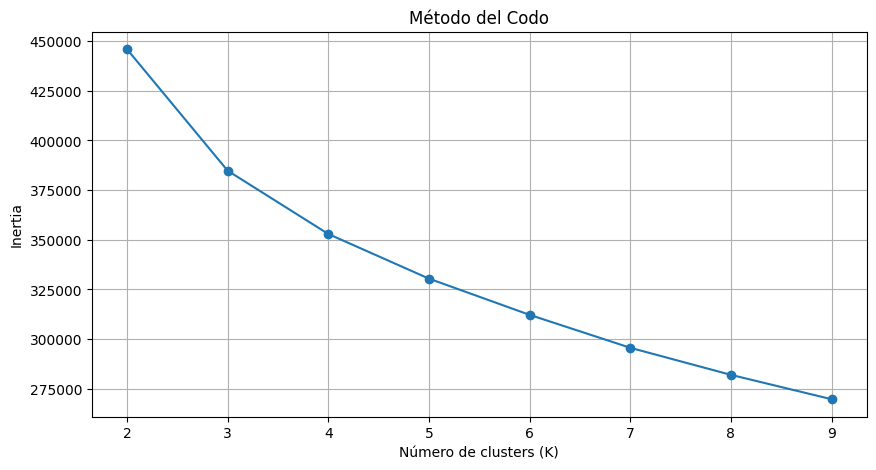

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    list(ks),
    inertias,
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.title("Método del Codo")

plt.grid(True)

plt.show()

## 7. Silhouette Score

En esta sección se analiza la calidad de los clusters utilizando el silhouette score.

A diferencia de la inertia, esta métrica penaliza clusters mal separados.

El valor óptimo suele corresponder al máximo silhouette score observado.

La combinación de:

- método del codo
- silhouette score
- interpretación económica

permite seleccionar un número de clusters más robusto.

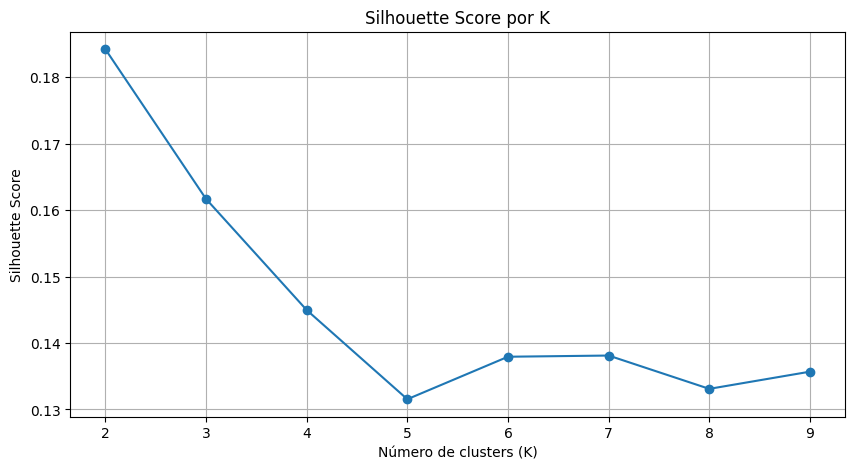

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    list(ks),
    silhouettes,
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por K")

plt.grid(True)

plt.show()

## 8. Comparación de distintos números de clusters

Con el objetivo de seleccionar un número adecuado de clusters, se comparan distintas configuraciones de K-Means para varios valores de K.

La evaluación combina:

- métricas cuantitativas (inertia y silhouette score)
- estabilidad de los clusters
- e interpretabilidad económica de los regímenes obtenidos

En modelos de clustering financiero, la elección óptima de K no depende únicamente de métricas geométricas, sino también de la capacidad del modelo para separar estados de mercado económicamente diferenciados.

In [13]:
KS_ANALIZAR = [3, 4, 5, 6]

resultados_k = {}

for k in KS_ANALIZAR:

    print("\n" + "=" * 60)
    print(f"ANÁLISIS PARA K = {k}")
    print("=" * 60)

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE
    )

    clusters = kmeans.fit_predict(X_scaled)

    df_temp = df_model.copy()
    df_temp["Cluster"] = clusters

    # ========================================================
    # DISTRIBUCIÓN
    # =========================================================

    print("\nDistribución de clusters:\n")

    conteo = (
        df_temp["Cluster"]
        .value_counts()
        .sort_index()
    )

    print(conteo)

    # =========================================================
    # CENTROIDES
    # =========================================================

    print("\nCentroides:\n")

    centroides = pd.DataFrame(
        kmeans.cluster_centers_,
        columns=features_disponibles
    )

    print(centroides.round(2))

    # ==========================================
    # PERFIL MEDIO
    # ==========================================

    print("\nPerfil promedio por cluster:\n")

    perfil = (
        df_temp
        .groupby("Cluster")[features_disponibles]
        .mean()
    )

    print(perfil.round(2))

    # Guardamos resultados
    resultados_k[k] = {
        "modelo": kmeans,
        "perfil": perfil,
        "centroides": centroides,
        "conteo": conteo
    }


ANÁLISIS PARA K = 3

Distribución de clusters:

Cluster
0    18772
1    28172
2    22532
Name: count, dtype: int64

Centroides:

   ALR12M_SKIP_Z  ALR6M_SKIP_Z  ALR1M_Z  MACD_Hist_Z  RSI_14_Z  \
0           0.11          0.15    -1.07        -0.96     -1.16   
1           0.64          0.55     0.28         0.16      0.43   
2          -0.90         -0.82     0.54         0.60      0.43   

   Volatilidad_252d_Z  ATR_14_Z  Vol_Relativo_Z  
0                0.14      0.57            0.36  
1               -0.50     -0.34           -0.10  
2                0.51     -0.05           -0.17  

Perfil promedio por cluster:

         ALR12M_SKIP_Z  ALR6M_SKIP_Z  ALR1M_Z  MACD_Hist_Z  RSI_14_Z  \
Cluster                                                                
0                 0.18          0.16    -1.20        -1.10     -1.22   
1                 0.91          0.67     0.27         0.17      0.45   
2                -1.21         -1.07     0.56         0.66      0.45   

         Vola

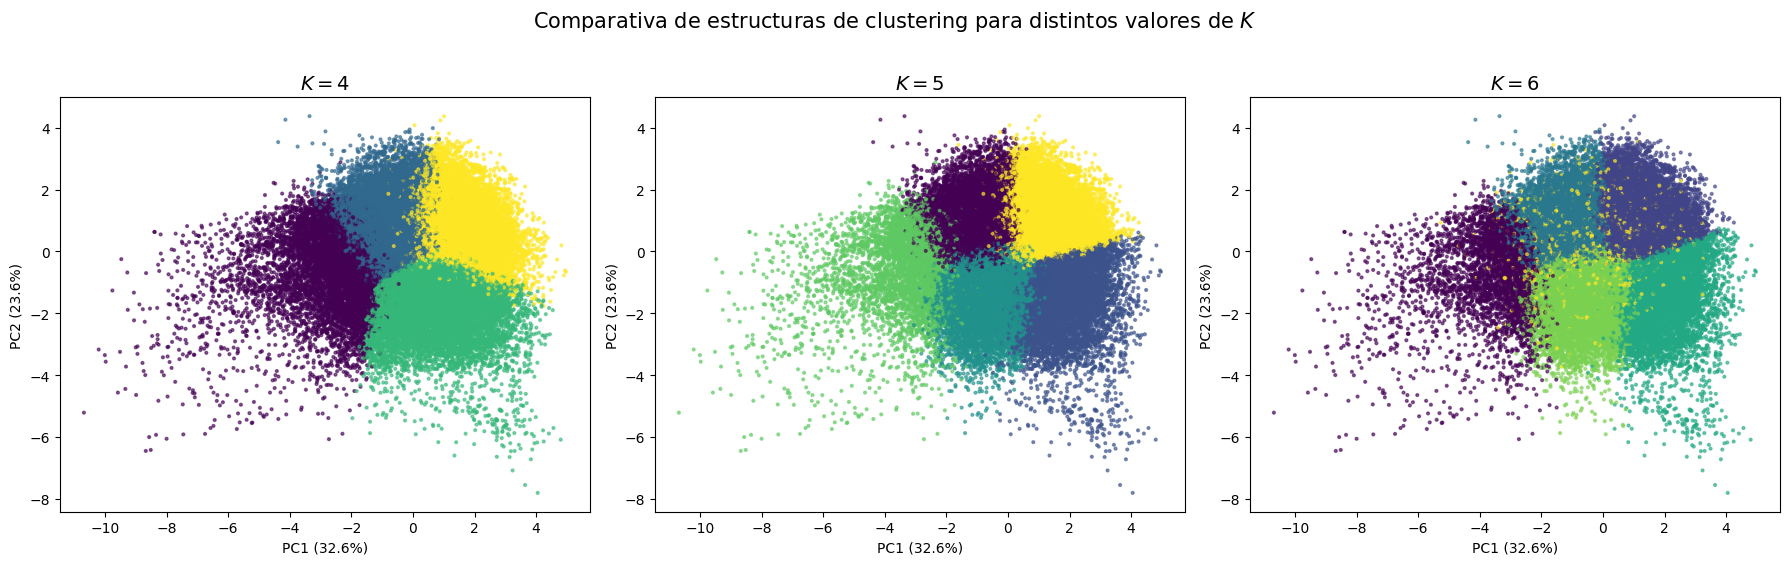

In [14]:
# ============================================================
# VISUALIZACIÓN COMPARATIVA DE PARTICIONES (K=3, K=5, K=6)
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for i, k in enumerate([4, 5, 6]):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE
    )
    labels = kmeans.fit_predict(X_scaled)
    
    axes[i].scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=labels, cmap='viridis', s=4, alpha=0.6
    )
    axes[i].set_title(f'$K = {k}$', fontsize=14)
    axes[i].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    axes[i].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.suptitle(
    'Comparativa de estructuras de clustering para distintos valores de $K$',
    fontsize=15, y=1.02
)
plt.tight_layout()
#plt.savefig('media/kmeans_comparativa_k.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretación comparativa de los clusters para distintos valores de K

Con el objetivo de determinar una segmentación adecuada del espacio financiero, se compararon configuraciones de K-Means para distintos valores de \( K \).

La evaluación se realizó considerando tanto métricas geométricas como la interpretación económica de los clusters obtenidos.

---

# Análisis para K = 3

La configuración con tres clusters genera una estructura relativamente simple y compacta, aunque todavía demasiado agregada desde el punto de vista económico.

## Cluster 0 — Régimen alcista estable

**Características:**
- Momentum positivo en todos los horizontes
- RSI y MACD positivos
- Baja volatilidad

**Interpretación:**

Representa un entorno alcista estructuralmente sólido y estable, con continuidad del momentum y bajo nivel de incertidumbre.

---

## Cluster 1 — Corrección o estrés de corto plazo

**Características:**
- ALR1M fuertemente negativo
- MACD y RSI muy negativos
- ATR y volumen relativo elevados

**Interpretación:**

Representa fases de deterioro brusco de corto plazo, asociadas a episodios de corrección intensa o estrés temporal de mercado.

---

## Cluster 2 — Rebote dentro de tendencia bajista

**Características:**
- Momentum estructural negativo
- Rebote técnico de corto plazo
- Volatilidad relativamente elevada

**Interpretación:**

Corresponde a recuperaciones temporales dentro de mercados estructuralmente débiles.

---

# Análisis para K = 4

Con cuatro clusters aparece una separación más rica de los regímenes de mercado.

## Cluster 0 — Capitulation / estrés extremo

**Características:**
- ALR1M extremadamente negativo
- RSI y MACD muy deteriorados
- ATR muy elevado
- Volumen relativo alto

**Interpretación:**

Representa episodios de capitulación y ventas forzadas.

---

## Cluster 1 — Régimen alcista estable

**Características:**
- Momentum positivo
- Baja volatilidad
- RSI elevado

**Interpretación:**

Entorno favorable para estrategias momentum y seguimiento de tendencia.

---

## Cluster 2 — Pullback alcista

**Características:**
- Momentum estructural positivo
- Debilidad temporal de corto plazo
- Baja volatilidad

**Interpretación:**

Correcciones dentro de una tendencia alcista principal.

---

## Cluster 3 — Mercado bajista con rebotes técnicos

**Características:**
- Momentum negativo estructural
- Señales técnicas mixtas
- Volatilidad elevada

**Interpretación:**

Mercados débiles con episodios de recuperación parcial.

---

# Análisis para K = 5

La configuración con cinco clusters proporciona la estructura más interpretable económicamente.

## Cluster 0 — Régimen bajista moderado

**Características:**
- Momentum negativo generalizado
- RSI negativo
- Volatilidad moderadamente elevada

**Interpretación:**

Mercado bajista sostenido sin eventos extremos de capitulación.

---

## Cluster 1 — Bear market rally

**Características:**
- Momentum estructural muy negativo
- Fuerte recuperación a corto plazo
- RSI y MACD positivos
- Volatilidad alta

**Interpretación:**

Rebotes técnicos dentro de un entorno bajista.

---

## Cluster 2 — Régimen alcista estable

**Características:**
- Momentum positivo en todos los horizontes
- Baja volatilidad
- RSI elevado

**Interpretación:**

Tendencia alcista consistente y estable.

---

## Cluster 3 — Pullback dentro de mercado alcista

**Características:**
- Momentum positivo a largo plazo
- Corrección temporal de corto plazo
- Baja volatilidad

**Interpretación:**

Fases de consolidación dentro de mercados alcistas.

---

## Cluster 4 — Estrés extremo / capitulación

**Características:**
- ALR1M extremadamente negativo
- MACD y RSI profundamente negativos
- ATR extremadamente elevado
- Volumen relativo muy alto

**Interpretación:**

Eventos de estrés severo de mercado asociados a shocks y ventas masivas.

---

# Análisis para K = 6

Con seis clusters el modelo comienza a fragmentar excesivamente el espacio vectorial.

Aunque algunos grupos adicionales presentan interés, aparecen clusters parcialmente redundantes.

## Cluster 0 — Pullback alcista

Corrección temporal dentro de tendencia positiva.

---

## Cluster 1 — Volumen anómalo aislado

**Características:**
- Volumen relativo extremadamente alto
- Variables restantes relativamente neutras

**Interpretación:**

Cluster especializado en anomalías de volumen sin estructura clara de momentum.

---

## Cluster 2 — Estrés extremo de mercado

**Características:**
- Colapso de corto plazo
- ATR extremadamente elevado
- Elevada volatilidad

**Interpretación:**

Capitulación severa.

---

## Cluster 3 — Bear market rally

Recuperación técnica dentro de mercado bajista.

---

## Cluster 4 — Régimen bajista moderado

Debilidad estructural persistente.

---

## Cluster 5 — Régimen alcista estable

Momentum positivo y baja volatilidad.

---

# Conclusión final

La configuración \( K = 5 \) proporciona el mejor equilibrio entre:

- separación estadística
- estabilidad estructural
- e interpretabilidad económica

Con cinco clusters el modelo logra distinguir de forma coherente:

- mercados alcistas
- correcciones alcistas
- mercados bajistas
- rebotes técnicos bajistas
- y episodios de capitulación

Por este motivo, se selecciona finalmente \( K = 5 \) como configuración óptima para la modelización de regímenes de mercado.

## 9. Entrenamiento final de K-Means

Una vez seleccionado el número óptimo de clusters, se entrena el modelo final de K-Means.

El algoritmo divide el espacio financiero en distintos regímenes de comportamiento similares.

Cada observación será asignada al cluster cuyo centroide se encuentre más próximo en términos de distancia euclidiana.

In [15]:
# AJUSTAR EN FUNCIÓN DE LOS GRÁFICOS
#K_FINAL = 4
K_FINAL = 5

print("\n" + "=" * 60)
print(f"ENTRENANDO K-MEANS FINAL (K={K_FINAL})")
print("=" * 60)

kmeans_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE
)

clusters = kmeans_final.fit_predict(X_scaled)


ENTRENANDO K-MEANS FINAL (K=5)


## 10. Asignación de clusters

Tras el entrenamiento del modelo, cada observación recibe una etiqueta de cluster.

Estas etiquetas representan regímenes de mercado detectados automáticamente por el algoritmo.

A partir de este momento es posible estudiar:

- comportamiento medio
- volatilidad
- momentum
- estructura técnica

de cada grupo identificado.

In [16]:
df_model["Cluster"] = clusters

## 11. Distribución de clusters

Se analiza cuántas observaciones han sido asignadas a cada cluster.

Esto permite detectar:

- clusters dominantes
- clusters minoritarios
- posibles desbalances estructurales

Clusters excesivamente pequeños podrían indicar:
- subregímenes específicos
- eventos raros
- o sobresegmentación

In [17]:
print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE CLUSTERS")
print("=" * 60)

conteo = (
    df_model["Cluster"]
    .value_counts()
    .sort_index()
)

print(conteo)


DISTRIBUCIÓN DE CLUSTERS
Cluster
0    18066
1    11623
2    15211
3     5266
4    19310
Name: count, dtype: int64


## 12. Análisis de centroides

Los centroides representan el perfil promedio de cada cluster en el espacio financiero multidimensional.

Cada coordenada del centroide indica el valor medio estandarizado de una variable dentro del régimen correspondiente.

El análisis de centroides permite interpretar económicamente los clusters obtenidos.

In [18]:
print("\n" + "=" * 60)
print("CENTROIDES")
print("=" * 60)

centroides = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=features_disponibles
)

print(centroides.round(2))


CENTROIDES
   ALR12M_SKIP_Z  ALR6M_SKIP_Z  ALR1M_Z  MACD_Hist_Z  RSI_14_Z  \
0           0.77          0.71    -0.40        -0.45     -0.47   
1          -1.07         -1.00     0.92         0.86      0.72   
2          -0.70         -0.66    -0.50        -0.20     -0.63   
3           0.30          0.39    -1.68        -1.75     -1.56   
4           0.40          0.35     0.67         0.54      0.93   

   Volatilidad_252d_Z  ATR_14_Z  Vol_Relativo_Z  
0               -0.41     -0.10           -0.19  
1                0.72      0.05           -0.25  
2                0.39      0.00           -0.04  
3                0.40      1.56            1.08  
4               -0.47     -0.36            0.07  


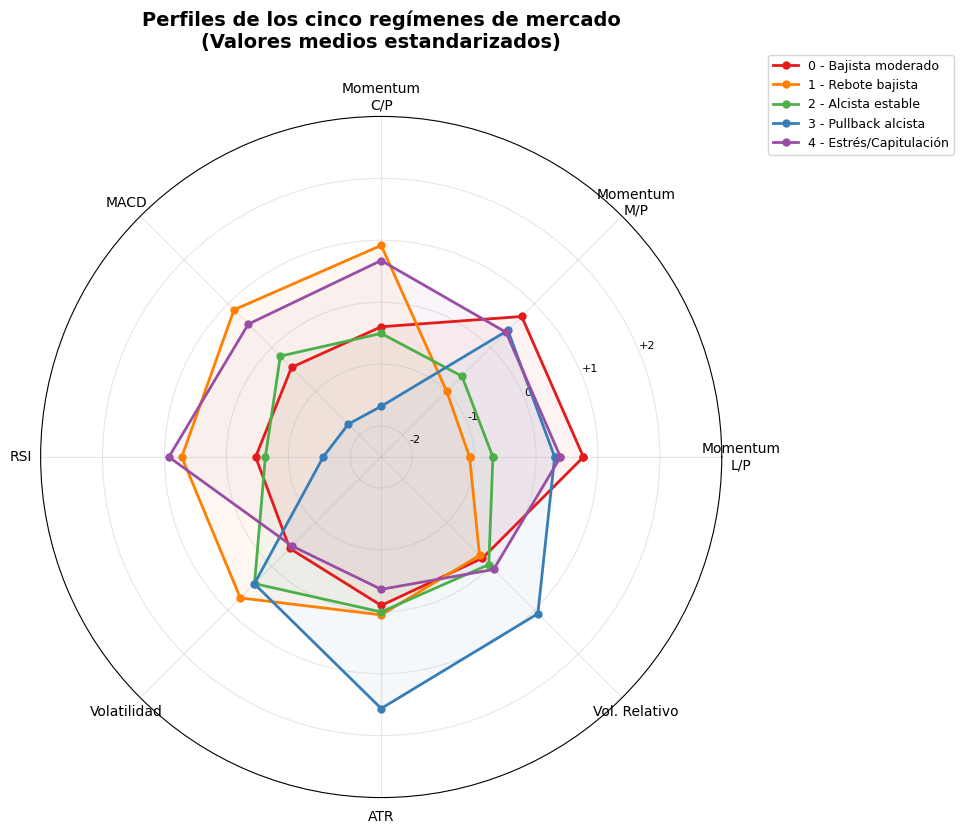

In [19]:
# ============================================================
# VISUALIZACIÓN DE PERFILES DE CLUSTERS (RADAR CHART)
# ============================================================

import numpy as np
from math import pi

# Usamos los centroides (valores medios estandarizados)
centroides = kmeans_final.cluster_centers_
features = features_disponibles
n_features = len(features)

# Nombres más legibles para el gráfico
nombres_features = [
    'Momentum\nL/P',
    'Momentum\nM/P', 
    'Momentum\nC/P',
    'MACD',
    'RSI',
    'Volatilidad',
    'ATR',
    'Vol. Relativo'
]

# Etiquetas de los clusters
cluster_names = [
    '0 - Bajista moderado',
    '1 - Rebote bajista',
    '2 - Alcista estable',
    '3 - Pullback alcista',
    '4 - Estrés/Capitulación'
]

# Colores para cada cluster
colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8', '#984ea3']

# Ángulos para el radar
angles = [n / float(n_features) * 2 * pi for n in range(n_features)]
angles += angles[:1]  # Cerrar el polígono

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i in range(5):
    values = centroides[i].tolist()
    values += values[:1]  # Cerrar el polígono
    
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i], 
            label=cluster_names[i], markersize=5)
    ax.fill(angles, values, alpha=0.05, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(nombres_features, fontsize=10)
ax.set_ylim(-2.5, 3.0)
ax.set_yticks([-2, -1, 0, 1, 2])
ax.set_yticklabels(['-2', '-1', '0', '+1', '+2'], fontsize=8)
ax.set_title('Perfiles de los cinco regímenes de mercado\n(Valores medios estandarizados)', 
             fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Perfil económico de los clusters

En esta sección se calcula el promedio real de las variables financieras para cada cluster.

Esto permite transformar resultados matemáticos en interpretaciones económicas concretas.

Por ejemplo:

- clusters con momentum positivo y volatilidad baja podrían representar mercados alcistas estables
- clusters con volatilidad extrema y ATR elevado podrían representar períodos de estrés financiero
- clusters con momentum negativo sostenido podrían asociarse a mercados bajistas

In [20]:
print("\n" + "=" * 60)
print("PERFIL PROMEDIO POR CLUSTER")
print("=" * 60)

perfil = (
    df_model
    .groupby("Cluster")[features_disponibles]
    .mean()
)

print(perfil.round(2))


PERFIL PROMEDIO POR CLUSTER
         ALR12M_SKIP_Z  ALR6M_SKIP_Z  ALR1M_Z  MACD_Hist_Z  RSI_14_Z  \
Cluster                                                                
0                 1.09          0.87    -0.46        -0.52     -0.50   
1                -1.46         -1.30     0.97         0.96      0.75   
2                -0.93         -0.86    -0.58        -0.23     -0.66   
3                 0.44          0.47    -1.87        -1.99     -1.64   
4                 0.57          0.41     0.70         0.59      0.97   

         Volatilidad_252d_Z  ATR_14_Z  Vol_Relativo_Z  
Cluster                                                
0                     -0.75      0.18           -0.21  
1                      1.17      0.39           -0.27  
2                      0.61      0.32           -0.08  
3                      0.62      2.48            0.92  
4                     -0.84     -0.18            0.02  


## 14. Exportación de resultados

Finalmente, se exporta el dataset enriquecido con las etiquetas de cluster.

Este archivo podrá utilizarse posteriormente para:

- visualización
- backtesting
- análisis temporal
- predicción de retornos
- análisis de transiciones entre regímenes

In [21]:
OUTPUT_CLUSTER = "../data/processed/05_dataset_clusters.csv"

df_model.to_csv(
    OUTPUT_CLUSTER,
    index=False,
    sep=";",
    decimal=","
)

print("\n" + "=" * 60)
print("EXPORTACIÓN")
print("=" * 60)

print(f"Archivo exportado: {OUTPUT_CLUSTER}")


EXPORTACIÓN
Archivo exportado: ../data/processed/05_dataset_clusters.csv


## Interpretación económica de los clusters (K=5)

Tras la aplicación de K-Means sobre el dataset purgado mediante DBSCAN, se obtienen cinco clusters que representan distintos regímenes de mercado. La interpretación se basa en el perfil medio de cada cluster en términos de momentum, volatilidad y indicadores técnicos.

---

### Cluster 0 — Régimen bajista moderado

**Perfil:**
- Momentum negativo generalizado
- MACD y RSI negativos
- Volatilidad moderadamente elevada

**Interpretación:**

Este cluster representa un mercado bajista sostenido sin episodios extremos de estrés.

Corresponde a fases de debilidad estructural sin capitulación.

---

### Cluster 1 — Rebote en mercado bajista (bear market rally)

**Perfil:**
- Momentum estructural negativo (ALR12M y ALR6M muy bajos)
- Fuerte rebote a corto plazo (ALR1M positivo)
- MACD y RSI elevados en el corto plazo
- Volatilidad elevada

**Interpretación:**

Este cluster representa rebotes técnicos dentro de un entorno bajista.

Corresponde a movimientos de recuperación temporal en mercados débiles.

---

### Cluster 2 — Régimen alcista fuerte (bull market estable)

**Perfil:**
- Momentum positivo en todos los horizontes (ALR12M, ALR6M, ALR1M)
- MACD y RSI elevados
- Volatilidad baja (Volatilidad_252d_Z negativa)
- ATR contenido

**Interpretación:**

Este cluster representa un régimen de tendencia alcista estable, caracterizado por continuidad del impulso positivo y baja incertidumbre.

Corresponde a entornos favorables para estrategias de seguimiento de tendencia.

---

### Cluster 3 — Pullback dentro de tendencia alcista

**Perfil:**
- Momentum positivo a largo plazo (ALR12M y ALR6M elevados)
- Debilidad a corto plazo (ALR1M negativo)
- MACD y RSI negativos en el corto plazo
- Volatilidad baja

**Interpretación:**

Este cluster refleja una corrección temporal dentro de una tendencia alcista estructural.

Corresponde a fases de consolidación dentro de mercados alcistas.

---

### Cluster 4 — Régimen de estrés o capitulación

**Perfil:**
- Caída extrema en momentum a corto plazo (ALR1M muy negativo)
- MACD y RSI profundamente negativos
- ATR extremadamente elevado
- Volatilidad elevada (Volatilidad_252d_Z positiva)
- Volumen relativo elevado

**Interpretación:**

Este cluster representa episodios de estrés extremo de mercado o capitulación.

Está asociado a shocks de mercado, ventas forzadas o eventos de alta incertidumbre.

---

## Conclusión general

La segmentación obtenida permite identificar cinco regímenes de mercado con interpretación económica diferenciada:

- Cluster 0 — Régimen bajista moderado
- Cluster 1 — Rebote en mercado bajista (bear market rally)
- Cluster 2 — Régimen alcista fuerte (bull market estable)
- Cluster 3 — Pullback dentro de tendencia alcista
- Cluster 4 — Régimen de estrés o capitulación

Esta estructura transforma el mercado desde un espacio continuo de variables en un conjunto discreto de estados de régimen, lo que permite posteriores análisis predictivos sobre retornos y comportamiento futuro de los activos.